# Image-to-Recipe Generation with GEMMA and LoRA (PEFT)
This notebook demonstrates how to fine-tune GEMMA (2B) using LoRA adapters on a Kaggle food image and recipe dataset.

In [ ]:
# Install required libraries
# If running on Colab:
!pip install transformers==4.38.0 peft==0.10.0 accelerate==0.30.0 torchvision pandas torch PIL huggingface_hub BitsAndBytesConfig
!pip install nltk==3.8.1 rouge-score==0.1.2 sentence-transformers==2.3.1
!pip install -U bitsandbytes
!pip install evaluate

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType
from torchvision import models, transforms
from torch.utils.data import Dataset
from PIL import Image
import torch, json, os
import pandas as pd
from transformers import EarlyStoppingCallback

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer, util
# import torch, pandas as pd


In [ ]:
# Turn on CUDA debugging
# import os
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [ ]:
from huggingface_hub import login, notebook_login, HfFolder

notebook_login()
hf_token = HfFolder.get_token()

# print(hf_token)

### Model preparation

In [3]:
import torch
import random
import numpy as np

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
random.seed(seed)
np.random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Load GEMMA-2B tokenizer & model (use bfloat16 or float16 if on GPU)
model_id = "google/gemma-2b"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float32, low_cpu_mem_usage=True)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [5]:
# Apply LoRA adapter using PEFT
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,    # default to 2 time r (how strong the update from low rank matrices are)
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.03,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

In [6]:
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 1,843,200 || all params: 2,508,015,616 || trainable%: 0.0735


### Load JSON

In [7]:
# Only if on colab need to unzip images

# import zipfile

# zip_path = "/content/data/Food Images.zip"
# extract_path = "/content/data/"  # Choose where to extract

# try:
#     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#         zip_ref.extractall(extract_path)
#     print(f"Successfully extracted to {extract_path}")
# except FileNotFoundError:
#     print(f"Error: {zip_path} not found.")
# except zipfile.BadZipFile:
#     print(f"Error: {zip_path} is not a valid ZIP file.")
# except Exception as e:
#     print(f"An error occurred: {e}")


In [8]:
# Load Kaggle-style recipes data
# with open("../Data/Kaggle/kaggle_cleaned_recipes.json", "r") as f:
#     data = json.load(f)

# colab command (comment out other)
with open("/content/drive/MyDrive/Colab Notebooks/GATech - CS7643/Project/data/Kaggle/kaggle_cleaned_recipes.json", "r") as f:
    data = json.load(f)


### Recipe Dataset Class

In [9]:
class RecipeDataset(Dataset):
    def __init__(self, data, image_folder, tokenizer, transform=None, max_length=256):
        self.data = data
        self.image_folder = image_folder
        self.tokenizer = tokenizer
        self.transform = transform or transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.max_length = max_length
        # initialize vision encoder ResNet (CNN)
        self.vision_encoder = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.vision_out_dim = self.vision_encoder.fc.in_features    # automatically detect output dim (resnet50=2048;resnet18=512)
        self.vision_encoder.fc = torch.nn.Identity()

        # Freeze the vision encoder (i.e. no backpropagation and only encoding)
        self.vision_encoder.eval()
        for param in self.vision_encoder.parameters():
            param.requires_grad = False

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        try:
            item = self.data[idx]
            image_filename = os.path.basename(item["image"])
            if not image_filename.lower().endswith((".jpg", ".jpeg", ".png")):
                image_filename += ".jpg"  # default to jpg
            image_path = os.path.join(self.image_folder, image_filename)
            image = Image.open(image_path).convert("RGB")
            image = self.transform(image)

            # Encode image to feature vector
            with torch.no_grad():
                # image_embedding = self.vision_encoder(image.unsqueeze(0)).squeeze(0) # shape [512]  #- can look to delete later
                image_tensor = image.unsqueeze(0).to(next(self.vision_encoder.parameters()).device)
                image_embedding = self.vision_encoder(image_tensor).squeeze(0).cpu()  # shape [512]

            # Prepare text
            prompt = "Generate a step-by-step recipe based on the dish in the image:"
            # prompt_options = [
            #     "Describe how to cook this dish.",
            #     "Give me the full recipe steps.",
            #     "How do you prepare this meal?",
            #     "Write the cooking instructions for the shown dish.",
            #     "What are the steps to make this dish?"
            # ]
            # prompt = random.choice(prompt_options)
            instructions = item["instructions"]

            input_ids = self.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=self.max_length).input_ids.squeeze(0)
            labels = self.tokenizer(instructions, return_tensors="pt", truncation=True, max_length=self.max_length).input_ids.squeeze(0)

            # Debug line
            # print(f"[{idx}] input_ids: {input_ids.shape}, labels: {labels.shape}, image_embedding: {image_embedding.shape}")
            # print(input_ids)
            # print(image_filename)

            return {
                "prompt_input_ids": input_ids,          # shape: [seq_len]
                "labels": labels,                       # shape: [seq_len]
                "image_embedding": image_embedding      # shape: [512]
            }
        except Exception as e:
          print(f"[ERROR] Sample {idx} failed: {e}")
          return None  # Let collator filter instead of dummy data

### Custom Image to Recipe Model Wrapper

In [10]:
class ImageToRecipeModel(torch.nn.Module):
    def __init__(self, base_model, embed_dim, tokenizer=None,use_cross_attention=False):
        super().__init__()
        self.base_model = base_model
        self.tokenizer = tokenizer
        # hidden_size = base_model.base_model.model.model.embed_tokens.weight.shape[1]
        hidden_size = base_model.base_model.get_input_embeddings().weight.shape[1]
        self.embedding_proj = nn.Sequential(
            nn.Linear(embed_dim, hidden_size),
            nn.GELU(),
            nn.Dropout(0.05),
            nn.Linear(hidden_size, hidden_size)
        )

        self.image_position_embedding = torch.nn.Parameter(torch.zeros(1, 1, hidden_size))
        torch.nn.init.normal_(self.image_position_embedding, std=0.02)

        # Apply safer initialization
        # torch.nn.init.kaiming_normal_(self.embedding_proj.weight, nonlinearity='relu')
        # init first layer
        torch.nn.init.xavier_uniform_(self.embedding_proj[0].weight)
        torch.nn.init.constant_(self.embedding_proj[0].bias, 0.0)
        # init final layer
        torch.nn.init.xavier_uniform_(self.embedding_proj[-1].weight)
        torch.nn.init.constant_(self.embedding_proj[-1].bias, 0.0)

        # Dropout layer
        self.dropout = torch.nn.Dropout(p=0.05)

        # Cross-attention flag
        self.use_cross_attention = use_cross_attention

        # Add simple cross-attention
        self.cross_attention_fusion = CrossAttentionFusion(hidden_size)

        # Freeze vision encoder externally before passing in
        self.vision_encoder = None  # Set separately outside

    def get_input_embeddings(self):
        if hasattr(self.base_model, 'get_input_embeddings'):
            return self.base_model.get_input_embeddings()
        elif hasattr(self.base_model, 'base_model') and hasattr(self.base_model.base_model, 'get_input_embeddings'):
            return self.base_model.base_model.get_input_embeddings()
        else:
            raise AttributeError("Could not find get_input_embeddings in base_model")

    def set_input_embeddings(self, new_embeddings):
        if hasattr(self.base_model, 'set_input_embeddings'):
            return self.base_model.set_input_embeddings(new_embeddings)
        elif hasattr(self.base_model, 'base_model') and hasattr(self.base_model.base_model, 'set_input_embeddings'):
            return self.base_model.base_model.set_input_embeddings(new_embeddings)
        else:
            raise AttributeError("Could not find set_input_embeddings in base_model")

    def forward(self, prompt_input_ids=None, image_embedding=None, labels=None):
        # Device alignment
        device = next(self.base_model.parameters()).device

        if prompt_input_ids is not None:
            prompt_input_ids = prompt_input_ids.to(device)
        if image_embedding is not None:
            image_embedding = image_embedding.to(device)
        if labels is not None:
            labels = labels.to(device)

        # Project image embedding
        image_embedding = image_embedding.to(dtype=next(self.base_model.parameters()).dtype)

        # Project image to hidden space
        projected_image = self.embedding_proj(image_embedding)
        # projected_image = F.normalize(self.embedding_proj(image_embedding), dim=-1)  # [B, hidden_size]

        # Always compute embeddings
        input_embeds = self.base_model.get_input_embeddings()(prompt_input_ids)
        avg_prompt_embedding = input_embeds.mean(dim=1)
        # Compute similarity between image and prompt tokens
        # Compute prompt stats only in training mode
        if self.training and torch.is_grad_enabled():
            prompt_norm = avg_prompt_embedding.norm(dim=1).mean().item()
            print(f"[DEBUG] prompt norm: {prompt_norm:.4f}")
        proj_image = projected_image  # [B, hidden]

        # Normalize for cosine similarity
        norm_prompt = avg_prompt_embedding / avg_prompt_embedding.norm(dim=1, keepdim=True)
        norm_image = proj_image / proj_image.norm(dim=1, keepdim=True)

        cosine_sim = (norm_prompt * norm_image).sum(dim=1)  # [B]
        print(f"[DEBUG] Avg Cosine Sim (image vs prompt): {cosine_sim.mean().item():.4f}")

        # Add this block
        if self.training and torch.is_grad_enabled():
            image_norm = projected_image.norm(dim=1).mean().item()
            prompt_norm = avg_prompt_embedding.norm(dim=1).mean().item()
            print(f"[DEBUG] image norm: {image_norm:.4f} | prompt norm: {prompt_norm:.4f}")

        if self.use_cross_attention:
            inputs_embeds = self.cross_attention_fusion(input_embeds, projected_image)
        else:
            # Non-cross-attention path: concat image + token embeddings
            projected_image = projected_image.unsqueeze(1)  # [B, 1, H]
            image_embed_with_pos = projected_image + self.image_position_embedding  # [B, 1, H]
            inputs_embeds = torch.cat([image_embed_with_pos, input_embeds], dim=1)  # [B, T+1, H]

        # Optional: apply dropout
        if self.training:
            inputs_embeds = self.dropout(inputs_embeds)
        # Optional: add small gaussian noise to avoid mode collpase only during training
        # if self.training:
        #     inputs_embeds = inputs_embeds + 0.005 * torch.randn_like(inputs_embeds)

        if labels is not None and labels.shape[1] != inputs_embeds.shape[1]:
            min_len = min(labels.shape[1], inputs_embeds.shape[1])
            labels = labels[:, :min_len]
            inputs_embeds = inputs_embeds[:, :min_len, :]

        output = self.base_model(
            inputs_embeds=inputs_embeds,
            labels=labels
        )

        return {'loss': output.loss, 'logits': output.logits}

    def cross_attention_fusion(self, input_embeds, image_vector):
        """
        input_embeds: [B, T, H]
        image_vector: [B, H]
        returns fused_embeds: [B, T, H]
        """
        B, T, H = input_embeds.shape
        query = input_embeds
        key = value = image_vector.unsqueeze(1)  # [B, 1, H]

        attn_scores = torch.matmul(query, key.transpose(1, 2)) / (H ** 0.5)  # [B, T, 1]
        attn_weights = torch.softmax(attn_scores, dim=1)  # [B, T, 1]
        attn_output = attn_weights * value  # [B, T, H]
        return query + attn_output  # simple residual

    def generate_with_image(self, prompt_input_ids, image_embedding, **generate_kwargs):
        # 1. Get device and dtype from the wrapper model itself
        model_device = next(self.parameters()).device
        target_dtype = self.embedding_proj[0].weight.dtype

        print("proj weight dtype:", self.embedding_proj[0].weight.dtype)
        print("model_device:", next(self.parameters()).device)
        print("lm_head dtype:", self.base_model.lm_head.weight.dtype)

        # image_embedding = image_embedding.to(device=model_device, dtype=model_dtype)
        image_embedding = image_embedding.to(device=model_device, dtype=target_dtype)
        prompt_input_ids = prompt_input_ids.to(device=model_device)

        # 2. Ensure either batched input or single input can all be handled
        if image_embedding.dim() == 1:
            image_embedding = image_embedding.unsqueeze(0)  # [1, hidden]
        if prompt_input_ids.dim() == 1:
            prompt_input_ids = prompt_input_ids.unsqueeze(0)  # [1, T]

        # 3. Project image embedding and concat with token embeddings
        prompt_embeds = self.base_model.get_input_embeddings()(prompt_input_ids).to(dtype=target_dtype) # [B, T, hidden]
        if self.use_cross_attention:
            inputs_embeds = self.cross_attention_fusion(prompt_embeds, image_embedding)
        else:
            projected_image = self.embedding_proj(image_embedding).unsqueeze(1)
            print("Projected image:", projected_image.shape, projected_image.dtype)
            image_embed_with_pos = projected_image + self.image_position_embedding  # [B, 1, H]
            inputs_embeds = torch.cat([image_embed_with_pos, prompt_embeds], dim=1)

        # Debug to see where NaN is coming from
        if torch.isnan(inputs_embeds).any() or torch.isinf(inputs_embeds).any():
            raise ValueError("Detected NaNs or Infs in inputs_embeds!")
        # Debug print
        print("Prompt embeds:", prompt_embeds.shape, prompt_embeds.dtype)

        # 4. Add attention mask
        attention_mask = torch.ones(inputs_embeds.shape[:2], dtype=torch.long, device=inputs_embeds.device)

        ## Debug print
        # print("image_embedding shape:", image_embedding.shape, image_embedding.dtype)
        # print("prompt_input_ids shape:", prompt_input_ids.shape)
        # print("prompt_embeds shape:", prompt_embeds.shape, prompt_embeds.dtype)
        # print("inputs_embeds shape:", inputs_embeds.shape, inputs_embeds.dtype)
        # print("lm_head dtype:", self.base_model.lm_head.weight.dtype)
        # print("embedding_proj dtype:", self.embedding_proj.weight.dtype)

        assert not torch.isnan(inputs_embeds).any(), "NaNs in inputs_embeds"
        assert not torch.isinf(inputs_embeds).any(), "Infs in inputs_embeds"

        # 5. Generate
        return self.base_model.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            **generate_kwargs
        )

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CrossAttentionFusion(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.query_norm = nn.LayerNorm(hidden_size)
        self.key_norm = nn.LayerNorm(hidden_size)
        self.value_norm = nn.LayerNorm(hidden_size)

        # Optional: projection for key/value (can help if image and text spaces differ too much)
        self.key_proj = nn.Linear(hidden_size, hidden_size)
        self.value_proj = nn.Linear(hidden_size, hidden_size)

        # Gating mechanism (learnable)
        self.gate = nn.Parameter(torch.ones(1))  # Initialized to 1 (full attention)

    def forward(self, input_embeds, image_vector):
        """
        input_embeds: [B, T, H] — token embeddings (query)
        image_vector: [B, H]    — projected image embedding
        returns fused_embeds: [B, T, H]
        """
        B, T, H = input_embeds.shape

        # Normalize
        Q = self.query_norm(input_embeds)         # [B, T, H]
        K = self.key_norm(image_vector).unsqueeze(1)  # [B, 1, H]
        V = self.value_norm(image_vector).unsqueeze(1)  # [B, 1, H]

        # Optional projection (can help)
        K = self.key_proj(K)  # [B, 1, H]
        V = self.value_proj(V)  # [B, 1, H]

        # Attention scores and weights
        attn_scores = torch.matmul(Q, K.transpose(-1, -2)) / (H ** 0.5)  # [B, T, 1]
        attn_weights = torch.softmax(attn_scores, dim=1)  # [B, T, 1]

        # Weighted attention output
        attn_output = attn_weights * V  # [B, T, H]

        # Gated residual fusion
        fused = Q + self.gate * attn_output  # learnable balance between query and attended image

        return fused

In [12]:
from transformers import TrainerCallback

class SampleGenerationCallback(TrainerCallback):
    def __init__(self, eval_dataset, tokenizer, model, every_n_steps=500, num_samples=3):
        self.eval_dataset = eval_dataset
        self.tokenizer = tokenizer
        self.model = model
        self.every_n_steps = every_n_steps
        self.num_samples = num_samples

    def on_step_end(self, args, state, control, **kwargs):
        if state.global_step % self.every_n_steps == 0 and state.global_step > 0:
            print("\n=== Generating samples at step", state.global_step, "===")
            self.model.eval()
            device = next(self.model.parameters()).device

            with torch.no_grad():
                batch = [self.eval_dataset[i] for i in range(self.num_samples)]
                input_ids = torch.stack([b["prompt_input_ids"] for b in batch]).to(device)
                image_embeds = torch.stack([b["image_embedding"] for b in batch]).to(device)

                # Generate
                generated_ids = self.model.generate_with_image(
                    input_ids,
                    image_embeds,
                    max_new_tokens=100,
                    do_sample=True,     # required for top-k to take effect
                    top_k=50,
                    temperature=0.7,
                    top_p=0.9,
                )

                # Decode
                decoded_preds = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
                decoded_labels = self.tokenizer.batch_decode(
                    [b["labels"] for b in batch], skip_special_tokens=True
                )

                for i in range(self.num_samples):
                    print(f"\n[Sample {i}]")
                    print("Prompt:", self.tokenizer.decode(batch[i]["prompt_input_ids"], skip_special_tokens=True))
                    print("Generated:", decoded_preds[i])
                    print("Ground Truth:", decoded_labels[i])
                    print("-" * 50)
            self.model.train()


In [13]:
from transformers import TrainerCallback

class CollapseDetectionCallback(TrainerCallback):
    def __init__(self, tokenizer, every_n_steps=100, threshold=0.8):
        self.tokenizer = tokenizer
        self.every_n_steps = every_n_steps
        self.threshold = threshold  # % of repeated tokens allowed before stopping

    def on_step_end(self, args, state, control, model=None, **kwargs):
        if state.global_step % self.every_n_steps == 0 and state.global_step > 0:
            model.eval()
            with torch.no_grad():
                # Simple test: generate a very short batch
                sample_input_ids = torch.tensor([[self.tokenizer.bos_token_id, self.tokenizer.pad_token_id]]).to(next(model.parameters()).device)
                sample_image_embed = torch.zeros((1, 2048)).to(next(model.parameters()).device)

                gen_ids = model.generate_with_image(sample_input_ids, sample_image_embed, max_new_tokens=30)
                decoded = self.tokenizer.decode(gen_ids[0], skip_special_tokens=True)

                # Check how repetitive the output is
                tokens = decoded.split()
                if len(tokens) == 0:
                    return control

                unique_tokens = len(set(tokens))
                repetitiveness = 1.0 - (unique_tokens / len(tokens))

                print(f"[Collapse Detection] Step {state.global_step} - repetitiveness: {repetitiveness:.2f}")

                if repetitiveness > self.threshold:
                    print("Detected collapse! Too much repetition. Stopping training early.")
                    control.should_training_stop = True
            model.train()
        return control

In [14]:
from transformers import TrainerCallback

class AggressiveUnfreezeCallback(TrainerCallback):
    def __init__(self, model, unfreeze_step=200):
        self.model = model
        self.unfreeze_step = unfreeze_step
        self.has_unfrozen = False

    def on_step_end(self, args, state, control, **kwargs):
        if not self.has_unfrozen and state.global_step >= self.unfreeze_step:
            print(f"\n Aggressively unfreezing decoder layers at step {state.global_step}...")
            for name, param in self.model.base_model.named_parameters():
                if any(layer in name for layer in ["layers.0", "layers.1", "layers.2", "layers.3", "layers.4", "layers.5", "layers.6", "norm", "embed_tokens"]):
                    param.requires_grad = True
            self.has_unfrozen = True

### Data Collator & Evaluation class

In [15]:
# Custom data_collator

from torch.nn.utils.rnn import pad_sequence

def get_image_to_recipe_collator(vision_out_dim):
    def collator(batch):
        batch = [item for item in batch if item is not None]
        if not batch:
          # Create dummy sample with proper device handling
            dummy = {
                "prompt_input_ids": torch.zeros(1, dtype=torch.long),
                "labels": torch.full((1, 1), -100, dtype=torch.long),
                "image_embedding": torch.zeros(vision_out_dim)
            }
            batch = [dummy]

        # Pad sequences
        input_ids = pad_sequence(
            [item["prompt_input_ids"] for item in batch],
            batch_first=True,
            padding_value=tokenizer.pad_token_id
        )

        labels = pad_sequence(
            [item["labels"] for item in batch],
            batch_first=True,
            padding_value=-100      # Keep -100 for loss calculation
        )

        # Prepend image token ignore label
        ignore_labels = torch.full((len(batch), 1), -100, dtype=torch.long)
        full_labels = torch.cat([ignore_labels, labels], dim=1)

        return {
            "prompt_input_ids": input_ids,
            "labels": full_labels,
            "image_embedding": torch.stack([item["image_embedding"] for item in batch])
        }
    return collator

In [16]:
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Initialize once globally
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
embedder = SentenceTransformer('all-MiniLM-L6-v2')

def compute_rouge_l(predictions, references):
    scores = []
    for pred, ref in zip(predictions, references):
        score = rouge.score(ref, pred)["rougeL"].fmeasure
        scores.append(score)
    return sum(scores) / len(scores)

def compute_cosine_similarity(predictions, references):
    pred_embeds = embedder.encode(predictions, convert_to_tensor=True)
    ref_embeds = embedder.encode(references, convert_to_tensor=True)

    cos_scores = cosine_similarity(pred_embeds.cpu(), ref_embeds.cpu())
    mean_cos_sim = cos_scores.diagonal().mean()  # only the matching pairs
    return mean_cos_sim

def compute_metrics(eval_preds):
    try:
        preds, labels = eval_preds
        if preds is None or labels is None:
            return {"eval_rougeL": 0.0, "eval_cosine_similarity": 0.0}
        # Remove first token from labels (image token ignore label)
        labels = labels[:, 1:]

        # Convert logits to token IDs
        pred_ids = np.argmax(preds, axis=-1)

        # Replace padding in labels
        labels = np.where(labels == -100, tokenizer.pad_token_id, labels)

        # Decode with error handling
        decoded_preds = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

        # Filter empty strings
        decoded_preds = [p if p.strip() else "<EMPTY>" for p in decoded_preds]
        decoded_labels = [l if l.strip() else "<EMPTY>" for l in decoded_labels]

        return {
            "eval_rougeL": compute_rouge_l(decoded_preds, decoded_labels),
            "eval_cosine_similarity": compute_cosine_similarity(decoded_preds, decoded_labels)
        }
    except Exception as e:
        print(f"Metric computation failed: {e}")
        return {"eval_rougeL": 0.0, "eval_cosine_similarity": 0.0}

In [17]:
from transformers import TrainerCallback
import matplotlib.pyplot as plt

class PlotMetricsCallback(TrainerCallback):
    def __init__(self):
        self.steps = []
        self.eval_rougeL = []
        self.eval_cosine = []

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None:
            return

        step = state.global_step

        rouge = metrics.get("eval_rougeL", None)
        cosine = metrics.get("eval_cosine_similarity", None)

        if rouge is not None:
            self.steps.append(step)
            self.eval_rougeL.append(rouge)

        if cosine is not None:
            self.eval_cosine.append(cosine)

        # Print a nice table row
        print(f"[Step {step}] Val RougeL={rouge:.4f} | CosineSim={cosine:.4f}")

        # Live plot
        plt.figure(figsize=(8,5))
        plt.plot(self.steps, self.eval_rougeL, label="eval_rougeL", marker="o")
        plt.plot(self.steps, self.eval_cosine, label="eval_cosine_similarity", marker="x")
        plt.xlabel("Step")
        plt.ylabel("Score")
        plt.title("Evaluation Metrics Over Time")
        plt.legend()
        plt.grid()
        plt.show()

In [18]:
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        prompt_input_ids = inputs.get("prompt_input_ids")
        image_embedding = inputs.get("image_embedding")

        outputs = model(
            prompt_input_ids=prompt_input_ids,
            image_embedding=image_embedding,
            labels=labels
        )
        loss = outputs["loss"]

        # Correct key for Trainer
        self.log({"loss": loss.detach().float().cpu().item()})

        return (loss, outputs) if return_outputs else loss


### Training arguments

In [28]:
# Prepare data and Trainer
from pathlib import Path

# Get the current working directory (e.g., Project Code/)
cwd = Path.cwd()
## Local path
# image_folder = cwd.parent / "Data" / "Kaggle" / "Food Images"
## Colab path
image_folder = "/content/data/Food Images"

train_dataset = RecipeDataset(data[:10000], image_folder, tokenizer)
eval_dataset = RecipeDataset(data[10000:11500], image_folder, tokenizer)

training_args = TrainingArguments(
    output_dir="./outputs",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=48,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=20,                    # Save more frequently due to small dataset
    save_steps=20,                   # Align eval/checkpoint frequency
    save_total_limit=2,               # Limit saved checkpoints to avoid clutter
    num_train_epochs=5,
    bf16=True,                        # On A100, turning this on
    # fp16=True,
    gradient_accumulation_steps=8,
    eval_accumulation_steps=4,        # Key to save memory
    learning_rate=2e-5,
    weight_decay=0.005,
    warmup_steps=150,                 # aim for 60% of the total steps on small fragile set like this - can be 30-50% on others (10000/batch/grad accum = steps per epoch to find total epoch steps)
    # logging_steps=5,
    # logging_strategy="steps",
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="loss",      # Can also be just loss, rougeL
    greater_is_better=False,
    dataloader_pin_memory=True,        # Required for CPU->GPU transfer
    remove_unused_columns=False,
    save_safetensors=False,
    lr_scheduler_type="cosine"
)

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define and freeze vision encoder
vision_encoder = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
vision_out_dim = vision_encoder.fc.in_features
vision_encoder.fc = torch.nn.Identity()


for p in vision_encoder.parameters():
    p.requires_grad = False

# # unfreeze resnet.layer4 and fc
# for name, param in vision_encoder.named_parameters():
#     if "layer4" in name or "fc" in name:
#         param.requires_grad = True
# vision_encoder.train().to(device)     # unfreeze partially

vision_encoder.eval().to(device)

# Assign to model
recipe_model = ImageToRecipeModel(
    base_model=model,  # <-- base_model (Gemma2B)
    embed_dim=vision_out_dim,
    tokenizer=tokenizer,
    use_cross_attention=True
)
recipe_model = recipe_model.to(device)
recipe_model.vision_encoder = vision_encoder

# Unfreeze token embeddings

for name, param in recipe_model.base_model.named_parameters():
    if "embed_tokens" in name:
        param.requires_grad = True

# OPTIONAL: Freeze early transformer layers ---
def freeze_early_layers(model, num_layers_to_freeze=6):
    for name, param in model.base_model.named_parameters():
        if any(f"layers.{i}." in name for i in range(num_layers_to_freeze)):
            param.requires_grad = False
    print(f"Frozen first {num_layers_to_freeze} layers of Gemma")

freeze_early_layers(recipe_model, num_layers_to_freeze=4)


# Define collator
collator = get_image_to_recipe_collator(vision_out_dim)

trainer = CustomTrainer(
    model=recipe_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=5, early_stopping_threshold=0.001),
        PlotMetricsCallback(),
        SampleGenerationCallback(eval_dataset, tokenizer, recipe_model, every_n_steps=20, num_samples=3),
        CollapseDetectionCallback(tokenizer, every_n_steps=40, threshold=0.8)
    ]
)

Frozen first 4 layers of Gemma


In [ ]:
import torch
import torch.nn.functional as F

# ==== Prep dummy inputs ====
model = recipe_model
model.train()

# Grab a batch from your dataset
sample = train_dataset[0]
prompt_ids = sample["prompt_input_ids"].unsqueeze(0).to(device)
image_embed = sample["image_embedding"].unsqueeze(0).to(device)
labels = sample["labels"].unsqueeze(0).to(device)

# ==== Forward pass ====
output = model(prompt_input_ids=prompt_ids, image_embedding=image_embed, labels=labels)
loss = output["loss"]
print("Loss:", loss.item())

# ==== Backward pass ====
loss.backward()

# ==== Check if embed_tokens has gradient ====
token_embeds = model.base_model.get_input_embeddings()
grad = token_embeds.weight.grad

if grad is not None:
    print("embed_tokens has gradient. Mean abs grad:", grad.abs().mean().item())
else:
    print("embed_tokens has NO gradient!")

# ==== Check prompt embedding norm ====
prompt_embed = token_embeds(prompt_ids)
prompt_norm = prompt_embed.norm(dim=-1).mean().item()
print("Prompt embedding norm:", prompt_norm)

### Validation of pipeline (Not required to rerun)

In [25]:
# Test metric computation before training
test_sample = eval_dataset[0]

# Ensure model is in eval mode
recipe_model.eval()

with torch.no_grad():
    # Inputs
    prompt_input_ids = test_sample["prompt_input_ids"]
    image_embedding = test_sample["image_embedding"]

    # Run generation
    generated_ids = recipe_model.generate_with_image(
        prompt_input_ids=prompt_input_ids,
        image_embedding=image_embedding,
        max_new_tokens=200,  # Or whatever you want
        do_sample=False      # Greedy decoding
    )

    # Decode
    decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(test_sample["labels"].unsqueeze(0), skip_special_tokens=True)

    # Evaluate
    print("Generated text:", decoded_preds[0])
    print("Ground truth:", decoded_labels[0])

    # Calculate metric manually
    rouge_score = compute_rouge_l(decoded_preds, decoded_labels)
    print(f"Validation Rouge-L: {rouge_score:.4f}")

# Switch back to train mode
recipe_model.train()

proj weight dtype: torch.float32
model_device: cuda:0
lm_head dtype: torch.float32
Projected image: torch.Size([1, 1, 2048]) torch.float32
Prompt embeds: torch.Size([1, 16, 2048]) torch.float32
Generated text: 



1. 1.





-  1990

2.

- 1991

3. 1991

 <strong> a. ( 19. 1992000

4. ( maneu. (1. ( .

  p. 1990

1.





- 1.

- 1990

2. 1991



- 1991. ANd 3. 1992.

- 1992.

- 1993. 1994. 1995.

- 1995. 1996. 1997. 1998. 1999. 2000. 2001. 20000.

- 
Ground truth: Preheat oven to 350°F. Brush 10-inch-diameter springform pan with oil. Line bottom with parchment paper round. Brush paper with oil. Place 2 tablespoons matzo meal in pan and shake to coat; tap out excess.
Combine remaining 2 tablespoons matzo meal, almond flour, and 1/3 cup sugar in medium bowl; whisk to blend. Place egg yolks in large bowl; place egg whites in another large bowl. Add 1/3 cup sugar to yolks. Using electric mixer, beat yolk mixture until thick and fluffy. Beat in 6 tablespoons olive oil, then lemon juice, ora

ImageToRecipeModel(
  (base_model): PeftModelForCausalLM(
    (base_model): LoraModel(
      (model): GemmaForCausalLM(
        (model): GemmaModel(
          (embed_tokens): Embedding(256000, 2048, padding_idx=0)
          (layers): ModuleList(
            (0-17): 18 x GemmaDecoderLayer(
              (self_attn): GemmaAttention(
                (q_proj): lora.Linear(
                  (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=2048, out_features=8, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=8, out_features=2048, bias=False)
                  )
                  (lora_embedding_A): ParameterDict()
                  (lora_embedding_B): ParameterDict()
                

In [28]:
# Test metric computation before training
test_sample = eval_dataset[0]

# Ensure model is in eval mode
recipe_model.eval()

# Verify evaluation pipeline before full training
eval_sample = eval_dataset[0]
with torch.no_grad():
    inputs = {
        "prompt_input_ids": eval_sample["prompt_input_ids"].unsqueeze(0),
        "image_embedding": eval_sample["image_embedding"].unsqueeze(0),
        "labels": eval_sample["labels"].unsqueeze(0)
    }
    outputs = recipe_model(**inputs)
    fake_preds = (outputs["logits"].cpu().numpy(), inputs["labels"].cpu().numpy())

print("Validation metrics:", compute_metrics(fake_preds))

# Switch back to train mode
recipe_model.train()

Validation metrics: {'eval_rougeL': 0.0, 'eval_cosine_similarity': np.float32(0.3563653)}


ImageToRecipeModel(
  (base_model): PeftModelForCausalLM(
    (base_model): LoraModel(
      (model): GemmaForCausalLM(
        (model): GemmaModel(
          (embed_tokens): Embedding(256000, 2048, padding_idx=0)
          (layers): ModuleList(
            (0-17): 18 x GemmaDecoderLayer(
              (self_attn): GemmaAttention(
                (q_proj): lora.Linear(
                  (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=2048, out_features=8, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=8, out_features=2048, bias=False)
                  )
                  (lora_embedding_A): ParameterDict()
                  (lora_embedding_B): ParameterDict()
                

### Train

In [85]:
# !rm -r ./outputs

[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0319
[DEBUG] image norm: 7.0945 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0207
[DEBUG] image norm: 7.1627 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0275
[DEBUG] image norm: 6.9201 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0262
[DEBUG] image norm: 6.6774 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0278
[DEBUG] image norm: 7.0523 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0314
[DEBUG] image norm: 7.2134 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0237
[DEBUG] image norm: 6.5887 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0343
[DEBUG] image norm: 6.6347 | prompt norm:

Step,Training Loss,Validation Loss,Rougel,Cosine Similarity
20,13.972470,13.825117,0.020836,0.065432
40,13.289079,13.132565,0.021613,0.101936
60,12.119813,12.120513,0.022503,0.159880
80,10.620095,10.530728,0.023037,0.206770
100,8.611111,8.240372,0.034783,0.147692


[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0196
[DEBUG] image norm: 7.4460 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0232
[DEBUG] image norm: 7.2274 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0356
[DEBUG] image norm: 7.0848 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0296
[DEBUG] image norm: 7.1165 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0342
[DEBUG] image norm: 7.3759 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0252
[DEBUG] image norm: 7.0767 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0274
[DEBUG] image norm: 7.3897 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0244
[DEBUG] image norm: 7.7193 | prompt norm:

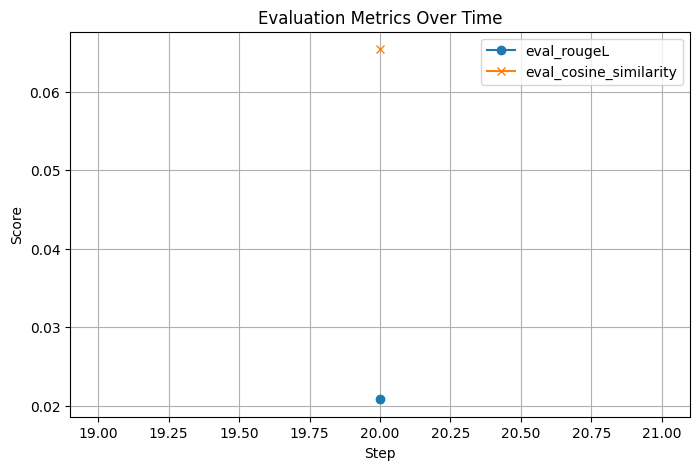

[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0291
[DEBUG] image norm: 7.1145 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0248
[DEBUG] image norm: 6.7971 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0262
[DEBUG] image norm: 7.0284 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0261
[DEBUG] image norm: 7.1079 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0262
[DEBUG] image norm: 7.0653 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0279
[DEBUG] image norm: 7.1999 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0276
[DEBUG] image norm: 6.8140 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0177
[DEBUG] image norm: 7.6739 | prompt norm:

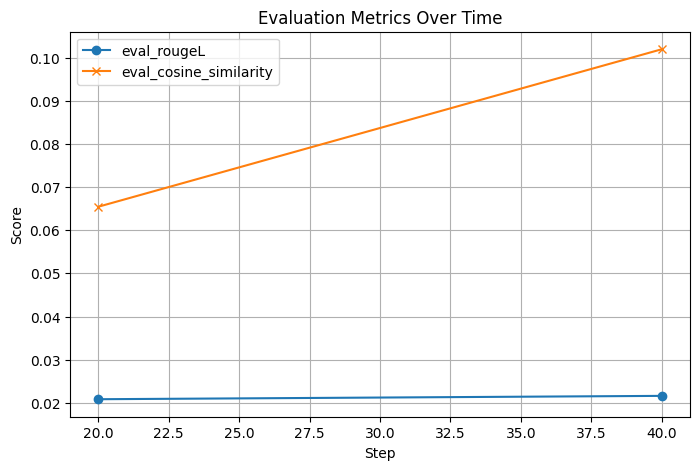

[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0314
[DEBUG] image norm: 6.9952 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0215
[DEBUG] image norm: 7.0189 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0234
[DEBUG] image norm: 7.2893 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0300
[DEBUG] image norm: 7.0999 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0292
[DEBUG] image norm: 6.8364 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0258
[DEBUG] image norm: 7.2907 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0331
[DEBUG] image norm: 7.0019 | prompt norm: 4.4023
[DEBUG] prompt norm: 4.4023
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0252
[DEBUG] image norm: 7.2282 | prompt norm:

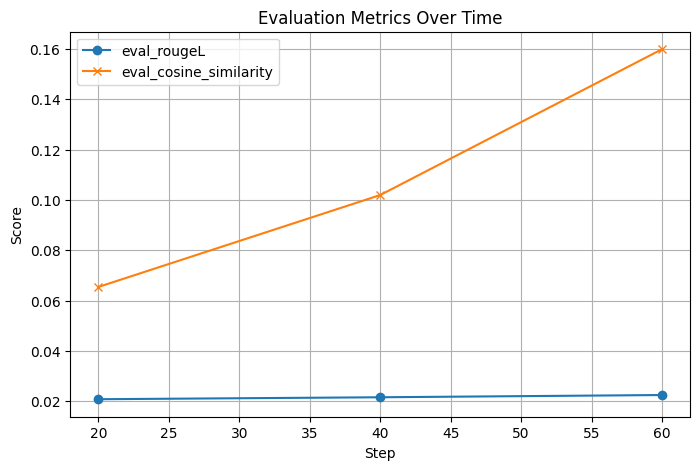

[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0269
[DEBUG] image norm: 7.4698 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0251
[DEBUG] image norm: 8.0715 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0297
[DEBUG] image norm: 7.1706 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0312
[DEBUG] image norm: 7.3136 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0352
[DEBUG] image norm: 7.3224 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0223
[DEBUG] image norm: 6.9295 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0325
[DEBUG] image norm: 6.8423 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0345
[DEBUG] image norm: 7.2898 | prompt norm:

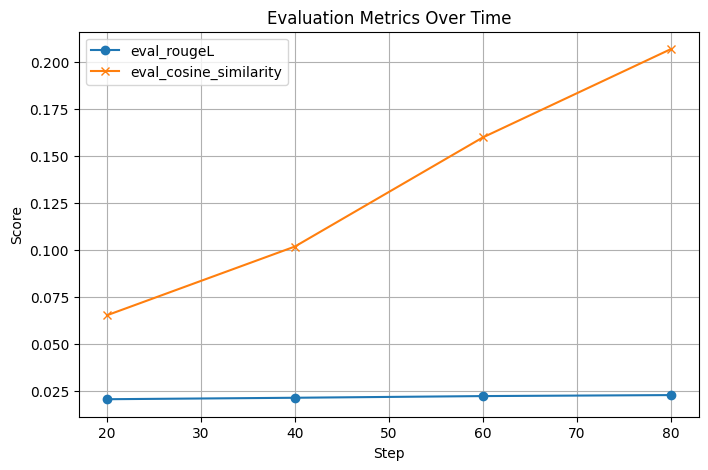

[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0285
[DEBUG] image norm: 8.4665 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0281
[DEBUG] image norm: 7.7556 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0234
[DEBUG] image norm: 7.8059 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0311
[DEBUG] image norm: 8.4701 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0318
[DEBUG] image norm: 8.1755 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0274
[DEBUG] image norm: 8.1654 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0358
[DEBUG] image norm: 8.2370 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0350
[DEBUG] image norm: 8.2335 | prompt norm:

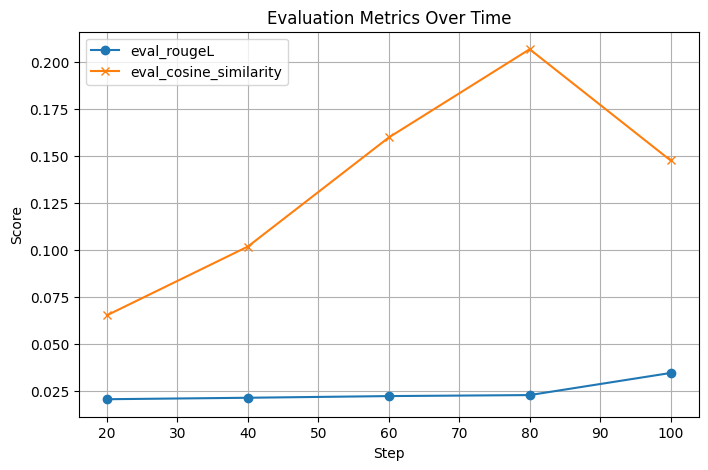

[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0289
[DEBUG] image norm: 9.7785 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0311
[DEBUG] image norm: 9.6831 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0263
[DEBUG] image norm: 9.5501 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0252
[DEBUG] image norm: 9.3606 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0277
[DEBUG] image norm: 9.9503 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0302
[DEBUG] image norm: 9.6432 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0222
[DEBUG] image norm: 9.2851 | prompt norm: 4.4024
[DEBUG] prompt norm: 4.4024
[DEBUG] Avg Cosine Sim (image vs prompt): 0.0330
[DEBUG] image norm: 9.3280 | prompt norm:

KeyboardInterrupt: 

In [29]:
# Train the model (LoRA tuned)

trainer.train()

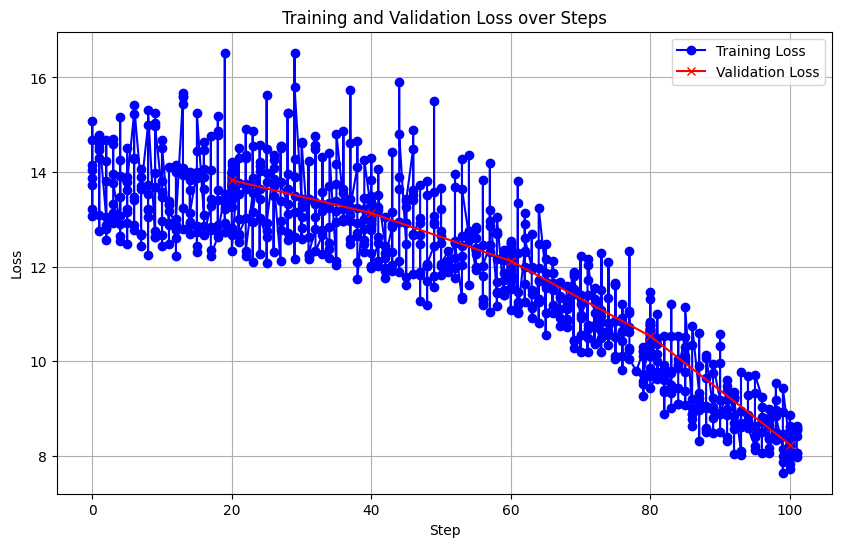

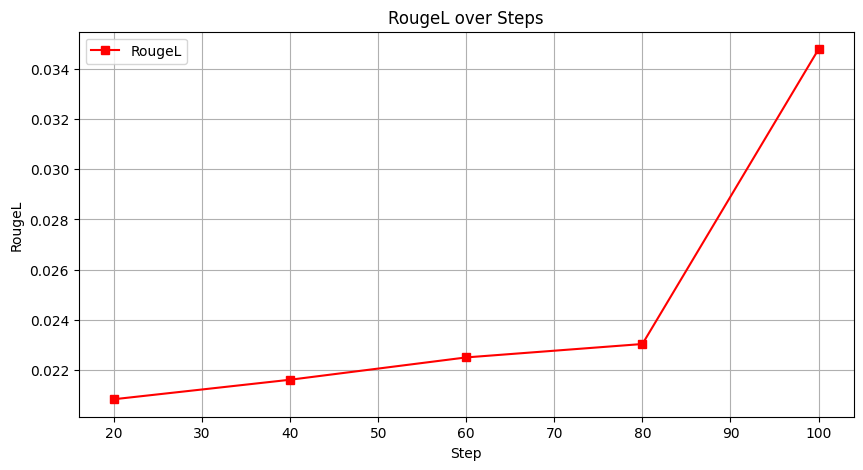

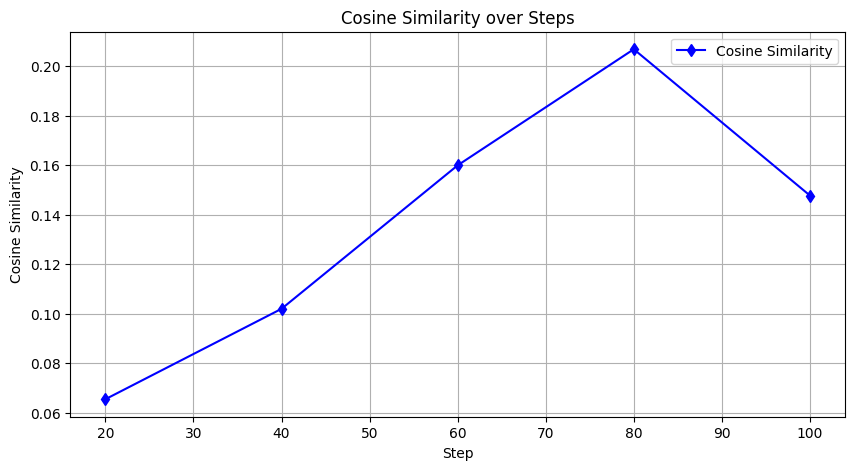

In [42]:
# Plot train v validation charts

import matplotlib.pyplot as plt

# Extract metrics
train_loss = []
val_loss = []
steps_train = []
steps_eval = []

for log in trainer.state.log_history:
    step = log.get("step", None)
    if step is not None:
        if "loss" in log and "eval_loss" not in log:
            train_loss.append(log["loss"])
            steps_train.append(step)
        if "eval_loss" in log:
            val_loss.append(log["eval_loss"])
            steps_eval.append(step)

# Plot Training Loss and Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(steps_train, train_loss, label="Training Loss", color='blue', marker='o')
plt.plot(steps_eval, val_loss, label="Validation Loss", color='red', marker='x')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss over Steps")
plt.grid(True)
plt.legend()
plt.show()

# Extract RougeL and Cosine Similarity
rougeL = []
cosine_sim = []
steps_eval_rouge_cos = []

for log in trainer.state.log_history:
    step = log.get("step", None)
    if step is not None and "eval_rougeL" in log:
        rougeL.append(log["eval_rougeL"])
        cosine_sim.append(log.get("eval_cosine_similarity", None))
        steps_eval_rouge_cos.append(step)

# Plot RougeL and Cosine Similarity
plt.figure(figsize=(10, 5))
plt.plot(steps_eval, rougeL, label="RougeL", color='red', marker='s')
plt.xlabel("Step")
plt.ylabel("RougeL")
plt.title("RougeL over Steps")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(steps_eval, cosine_sim, label="Cosine Similarity", color='blue', marker='d')
plt.xlabel("Step")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity over Steps")
plt.grid(True)
plt.legend()
plt.show()

In [36]:
eval_results = trainer.predict(eval_dataset)

preds = eval_results.predictions
labels = eval_results.label_ids

# Convert preds to token IDs
pred_ids = np.argmax(preds, axis=-1)

# Replace padding -100 with pad token id
labels = np.where(labels == -100, tokenizer.pad_token_id, labels)

# Decode
decoded_preds = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

# Print samples
for i in range(3):
    print(f"[Validation Sample {i}]")
    print(f"Prompt: {tokenizer.decode(eval_dataset[i]['prompt_input_ids'])}")
    print(f"Ground Truth: {decoded_labels[i]}")
    print(f"Generated: {decoded_preds[i]}")
    print("-" * 80)

Step,Training Loss,Validation Loss,Rougel,Cosine Similarity
20,24.152548,22.529276,0.028886,0.159296
40,18.077103,17.672747,0.030063,0.192677
60,15.552818,15.359294,0.030954,0.209278
80,13.500084,13.882021,0.032068,0.225920
100,12.360520,12.001479,0.032738,0.241616
120,10.961802,10.903746,0.032846,0.239169
140,10.440623,10.196058,0.032944,0.241605
160,9.737347,9.585074,0.031911,0.230914
180,8.868298,8.757321,0.028956,0.227578


[Validation Sample 0]
Prompt: <bos><image> Write detailed recipe instructions based on the dish shown.
Ground Truth: Preheat oven to 350°F. Brush 10-inch-diameter springform pan with oil. Line bottom with parchment paper round. Brush paper with oil. Place 2 tablespoons matzo meal in pan and shake to coat; tap out excess.
Combine remaining 2 tablespoons matzo meal, almond flour, and 1/3 cup sugar in medium bowl; whisk to blend. Place egg yolks in large bowl; place egg whites in another large bowl. Add 1/3 cup sugar to yolks. Using electric mixer, beat yolk mixture until thick and fluffy. Beat in 6 tablespoons olive oil, then lemon juice, orange juice, and lemon peel. Mix in dry ingredients. Add 1/2 teaspoon salt to whites; using clean dry beaters, beat until soft peaks form. Gradually add 1/3 cup sugar and beat until stiff but not dry. Fold whites into yolk mixture in 3 additions. Transfer batter to prepared pan. Sprinkle almonds over.
Bake cake until golden brown and tester inserted in

In [99]:
# # clear CUDA cache (Not always required)
# import gc, torch
# gc.collect()
# torch.cuda.empty_cache()

## Save Trained Model

In [31]:
# Save training log json

import json

# Save log history
with open("log_history.json", "w") as f:
    json.dump(trainer.state.log_history, f, indent=2)

print("Training logs saved to log_history.json!")



Training logs saved to log_history.json!


In [41]:
# # Reload training log history
# with open("log_history.json", "r") as f:
#     log_history = json.load(f)

# # We can also reassign it back to Trainer manually
# trainer.state.log_history = log_history

In [22]:
# Save Projection Embeddings

torch.save(recipe_model.embedding_proj.state_dict(), "embedding_proj.pth")
from google.colab import files
files.download('embedding_proj.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
# Save checkpoints to my google drive

!cp -r outputs/checkpoint-80 /content/drive/MyDrive/

In [21]:
from peft import PeftModel
import os

# Define save path
save_dir = "./lora_image_to_recipe"
os.makedirs(save_dir, exist_ok=True)

# final_model = PeftModel(model, lora_config)

# Save tokenizer
tokenizer.save_pretrained(save_dir)

if isinstance(model, PeftModel):
    model.save_pretrained(save_dir)
    print("LoRA model and tokenizer saved to:", save_dir)
else:
    print("Model is not a PeftModel. No adapter saved.")

LoRA model and tokenizer saved to: ./lora_image_to_recipe


In [27]:
# Colab only - Zip the folder
!zip -r 80steps_final.zip Final_80Step/

# Download it
from google.colab import files
files.download('80steps_final.zip')

  adding: Final_80Step/ (stored 0%)
  adding: Final_80Step/generated_vs_groundtruth.csv (deflated 74%)
  adding: Final_80Step/lora_image_to_recipe/ (stored 0%)
  adding: Final_80Step/lora_image_to_recipe/tokenizer_config.json (deflated 96%)
  adding: Final_80Step/lora_image_to_recipe/adapter_config.json (deflated 55%)
  adding: Final_80Step/lora_image_to_recipe/adapter_model.safetensors (deflated 41%)
  adding: Final_80Step/lora_image_to_recipe/tokenizer.model (deflated 51%)
  adding: Final_80Step/lora_image_to_recipe/special_tokens_map.json (deflated 76%)
  adding: Final_80Step/lora_image_to_recipe/README.md (deflated 66%)
  adding: Final_80Step/lora_image_to_recipe/tokenizer.json (deflated 84%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Colab only - Zip the folder
!zip -r lora_image_to_recipe.zip lora_image_to_recipe/

# Download it
from google.colab import files
files.download('lora_image_to_recipe.zip')

  adding: lora_image_to_recipe/ (stored 0%)
  adding: lora_image_to_recipe/tokenizer_config.json (deflated 96%)
  adding: lora_image_to_recipe/special_tokens_map.json (deflated 76%)
  adding: lora_image_to_recipe/adapter_model.safetensors (deflated 8%)
  adding: lora_image_to_recipe/adapter_config.json (deflated 55%)
  adding: lora_image_to_recipe/tokenizer.model (deflated 51%)
  adding: lora_image_to_recipe/README.md (deflated 66%)
  adding: lora_image_to_recipe/tokenizer.json (deflated 84%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Load Trained Model

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel, PeftConfig
from torchvision import models
import torch
from accelerate import infer_auto_device_map, dispatch_model

# 1. Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("google/gemma-2b")

# 2. Quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

# 3. Load PEFT config
peft_config = PeftConfig.from_pretrained("./lora_image_to_recipe")

# 4. Load quantized base model
base_model = AutoModelForCausalLM.from_pretrained(
    peft_config.base_model_name_or_path,
    quantization_config=bnb_config,
    device_map=None
)

# 5. Dispatch to memory-safe devices
device_map = infer_auto_device_map(
    base_model,
    max_memory={
        0: "8GiB",       # use `0` instead of "cuda:0"
        "cpu": "30GiB"
    },
    no_split_module_classes=["GemmaDecoderLayer"]
)
base_model = dispatch_model(base_model, device_map=device_map)

# 6. Load LoRA adapter
lora_model = PeftModel.from_pretrained(base_model, "./lora_image_to_recipe")

# 7. Init vision encoder
vision_encoder = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
vision_out_dim = vision_encoder.fc.in_features
vision_encoder.fc = torch.nn.Identity()  # Strip classification head
vision_encoder.eval()

# 8. Wrap into your custom multimodal model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

recipe_model = ImageToRecipeModel(
    base_model=lora_model,
    embed_dim=vision_out_dim,  # Pass dynamic embed_dim
    tokenizer=tokenizer,
    use_cross_attention=False
)
recipe_model.vision_encoder = vision_encoder  #  Attach vision encoder
for param in recipe_model.embedding_proj.parameters():
    param.requires_grad = True

recipe_model.embedding_proj = recipe_model.embedding_proj.to(dtype=lora_model.lm_head.weight.dtype)

# 9. Final setup
recipe_model.to(device).eval()
recipe_model.vision_encoder.to(device).eval()

# 10. Print trainable parameters (manually)
def print_trainable_parameters(model):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"trainable params: {trainable_params:,} || all params: {total_params:,} || trainable%: {100 * trainable_params / total_params:.2f}")

print_trainable_parameters(recipe_model)
torch.save({"model_state_dict": recipe_model.state_dict(), "vision_out_dim": vision_out_dim}, "image_to_recipe_full.pt")


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 27,704,384 || all params: 1,543,894,080 || trainable%: 1.79


In [ ]:
# # In future - can use the code below to load from image_to_recipe_full.pt
# # Load vision_out_dim
# checkpoint = torch.load("image_to_recipe_full.pt", map_location="cpu")
# vision_out_dim = checkpoint["vision_out_dim"]

# # Reload tokenizer
# tokenizer = AutoTokenizer.from_pretrained("./lora_image_to_recipe")

# # Reload base model
# base_model = AutoModelForCausalLM.from_pretrained("google/gemma-2b")

# # Attach LoRA adapter
# lora_model = PeftModel.from_pretrained(base_model, "./lora_image_to_recipe")

# # Build vision encoder
# vision_encoder = models.resnet50(pretrained=True)
# vision_encoder.fc = torch.nn.Identity()
# vision_encoder.eval()

# # Wrap
# recipe_model = ImageToRecipeModel(
#     base_model=lora_model,
#     embed_dim=vision_out_dim,
#     tokenizer=tokenizer
# )
# recipe_model.vision_encoder = vision_encoder

# # Load saved weights
# recipe_model.load_state_dict(checkpoint["model_state_dict"])
# recipe_model = recipe_model.to("cuda" if torch.cuda.is_available() else "cpu").eval()
# vision_encoder = vision_encoder.to("cuda" if torch.cuda.is_available() else "cpu").eval()

### Evaluation

In [19]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from torchvision import models

# 1. Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load ResNet50
vision_encoder = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
vision_out_dim = vision_encoder.fc.in_features  # save before replacing
vision_encoder.fc = torch.nn.Identity()
for p in vision_encoder.parameters():
    p.requires_grad = False
vision_encoder.eval().to(device)

# 3. Load base Gemma model and tokenizer
base_model = AutoModelForCausalLM.from_pretrained("google/gemma-2b", torch_dtype=torch.float32)
tokenizer = AutoTokenizer.from_pretrained("google/gemma-2b")

# 4. Rebuild your full multimodal model wrapper
# Rebuild wrapper
recipe_model = ImageToRecipeModel(
    base_model=base_model,
    embed_dim=vision_out_dim,  # use saved value here
    tokenizer=tokenizer,
    use_cross_attention=True
)
recipe_model.vision_encoder = vision_encoder
recipe_model = recipe_model.to(device)

# 5. Load raw trainer checkpoint
state_dict = torch.load("./outputs/checkpoint-80/pytorch_model.bin", map_location=device)
recipe_model.load_state_dict(state_dict, strict=False)  # strict=False allows minor mismatches
recipe_model.eval()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

ImageToRecipeModel(
  (base_model): GemmaForCausalLM(
    (model): GemmaModel(
      (embed_tokens): Embedding(256000, 2048, padding_idx=0)
      (layers): ModuleList(
        (0-17): 18 x GemmaDecoderLayer(
          (self_attn): GemmaAttention(
            (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
            (k_proj): Linear(in_features=2048, out_features=256, bias=False)
            (v_proj): Linear(in_features=2048, out_features=256, bias=False)
            (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          )
          (mlp): GemmaMLP(
            (gate_proj): Linear(in_features=2048, out_features=16384, bias=False)
            (up_proj): Linear(in_features=2048, out_features=16384, bias=False)
            (down_proj): Linear(in_features=16384, out_features=2048, bias=False)
            (act_fn): GELUActivation()
          )
          (input_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
          (post_attention_layernorm): GemmaRMSN

In [33]:
# import torch
# from tqdm import tqdm
# import evaluate
# import numpy as np
# from transformers import AutoModelForCausalLM, AutoTokenizer
# from torchvision import models

# # --- 1. Set Device ---
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # --- 2. Load Vision Encoder (Frozen ResNet50) ---
# vision_encoder = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
# vision_out_dim = vision_encoder.fc.in_features
# vision_encoder.fc = torch.nn.Identity()
# for p in vision_encoder.parameters():
#     p.requires_grad = False
# vision_encoder.eval().to(device)

# # --- 3. Load Gemma-2B (Causal LM Version!) ---
# base_model = AutoModelForCausalLM.from_pretrained(
#     "google/gemma-2b",
#     torch_dtype=torch.float32
# )
# tokenizer = AutoTokenizer.from_pretrained("google/gemma-2b")

# # --- 4. Load your trained LoRA checkpoint manually ---
# checkpoint_path = "./outputs/checkpoint-100/pytorch_model.bin"
# state_dict = torch.load(checkpoint_path, map_location=device)

# # --- 5. Rebuild Your Full Recipe Model ---
# recipe_model = ImageToRecipeModel(
#     base_model=base_model,
#     embed_dim=vision_out_dim,
#     tokenizer=tokenizer,
#     use_cross_attention=True
# )
# recipe_model.vision_encoder = vision_encoder
# recipe_model.load_state_dict(state_dict, strict=False)
# recipe_model = recipe_model.to(device)
# recipe_model.eval()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [24]:
import torch
from tqdm import tqdm
import evaluate
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
from torchvision import models

# # --- 1. Set Device ---
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # --- 2. Load Vision Encoder (Frozen ResNet50) ---
# vision_encoder = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
# vision_out_dim = vision_encoder.fc.in_features
# vision_encoder.fc = torch.nn.Identity()
# for p in vision_encoder.parameters():
#     p.requires_grad = False
# vision_encoder.eval().to(device)

# # --- 3. Load Gemma-2B (Causal LM Version!) ---
# base_model = AutoModelForCausalLM.from_pretrained(
#     "google/gemma-2b",
#     torch_dtype=torch.float32
# )
# tokenizer = AutoTokenizer.from_pretrained("google/gemma-2b")

# # --- 4. Load your trained LoRA checkpoint manually ---
# checkpoint_path = "./outputs/checkpoint-500/pytorch_model.bin"
# state_dict = torch.load(checkpoint_path, map_location=device)

# # --- 5. Rebuild Your Full Recipe Model ---
# recipe_model = ImageToRecipeModel(
#     base_model=base_model,
#     embed_dim=vision_out_dim,
#     tokenizer=tokenizer,
#     use_cross_attention=False
# )
# recipe_model.vision_encoder = vision_encoder
# recipe_model.load_state_dict(state_dict, strict=False)
# recipe_model = recipe_model.to(device)
# recipe_model.eval()

image_folder = "/content/data/Food Images"

test_dataset = RecipeDataset(data[11500:13000], image_folder, tokenizer)

collator = get_image_to_recipe_collator(vision_out_dim)


# --- 6. Prepare Eval Dataloader ---
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collator  # your collator
)

# --- 7. Set Metrics ---
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")
meteor = evaluate.load("meteor")
cosine = torch.nn.CosineSimilarity(dim=-1)

# --- 8. Reranking Config ---
top_k = 5     # how many samples per image
rerank_by = "rouge"  # choose between 'rouge', 'meteor', 'bleu'

# --- 9. Helper Functions ---
def clean_texts(texts):
    return [t.strip().lower() for t in texts]

def compute_rouge(pred, ref):
    score = rouge.compute(predictions=[pred], references=[ref], rouge_types=["rougeL"])["rougeL"]
    return score

def compute_bleu(pred, ref):
    score = bleu.compute(predictions=[pred.split()], references=[[ref.split()]])["bleu"]
    return score

def compute_meteor(pred, ref):
    score = meteor.compute(predictions=[pred], references=[ref])["meteor"]
    return score

# --- 10. Run Inference with Reranking ---
final_preds = []
final_refs = []

for batch in tqdm(test_loader, desc="Top-K reranking inference"):
    inputs = batch["prompt_input_ids"].to(device)
    pixel_values = batch["image_embedding"].to(device)
    attention_mask = (inputs != tokenizer.pad_token_id).long()
    labels = batch["labels"]

    with torch.no_grad():
        all_gen = recipe_model.base_model.generate(
            input_ids=inputs,
            attention_mask=attention_mask,
            max_new_tokens=256,
            num_return_sequences=top_k,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            eos_token_id=tokenizer.eos_token_id,
            num_beams=1,
        )
        all_gen = all_gen.view(inputs.size(0), top_k, -1)

    for idx in range(inputs.size(0)):
        valid_labels = labels[idx]
        valid_labels = valid_labels[(valid_labels >= 0) & (valid_labels < tokenizer.vocab_size)]  # valid id only
        valid_labels = valid_labels.tolist()

        refs = tokenizer.decode(valid_labels, skip_special_tokens=True).strip().lower()

        candidates = []
        for j in range(top_k):
            valid_candidate = all_gen[idx][j].detach().cpu()
            valid_candidate = valid_candidate[valid_candidate < tokenizer.vocab_size]
            valid_candidate = valid_candidate.tolist()
            candidates.append(tokenizer.decode(valid_candidate, skip_special_tokens=True).strip().lower())

        if rerank_by == "rouge":
            batch_scores = rouge.compute(predictions=candidates, references=[refs]*top_k, rouge_types=["rougeL"])["rougeL"]
            best_idx = np.argmax(batch_scores)
        elif rerank_by == "meteor":
            batch_scores = meteor.compute(predictions=candidates, references=[refs]*top_k)["meteor"]
            best_idx = np.argmax(batch_scores)
        elif rerank_by == "bleu":
            batch_scores = bleu.compute(predictions=[c.split() for c in candidates], references=[[refs.split()]] * top_k)["bleu"]
            best_idx = np.argmax(batch_scores)
        else:
            best_idx = 0  # fallback

        final_preds.append(candidates[best_idx])
        final_refs.append(refs)

# --- 11. Final Metrics After Reranking ---
rougeL_score = rouge.compute(predictions=final_preds, references=final_refs, rouge_types=["rougeL"])["rougeL"]
meteor_score = meteor.compute(predictions=final_preds, references=final_refs)["meteor"]
bleu_score = bleu.compute(predictions=final_preds, references=[[r] for r in final_refs])["bleu"]

# --- 12. Print nicely ---
print("========== Final Evaluation (Top-K reranked) ==========")
print(f"Rouge-L:  {rougeL_score*100:.2f}%")
print(f"METEOR:   {meteor_score*100:.2f}%")
print(f"BLEU-4:   {bleu_score*100:.2f}%")
print("=======================================================")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
Top-K reranking inference: 100%|██████████| 188/188 [30:08<00:00,  9.62s/it]


========== Final Evaluation (Top-K reranked) ==========
Rouge-L:  9.99%
METEOR:   12.53%
BLEU-4:   1.11%


In [25]:
# Print sample text output compared against ground truth
print("="*80)
for i in range(20):
    print(f"[Sample {i+1}]")
    print(f"Ground Truth : {final_refs[i]}")
    print(f"Generated    : {final_preds[i]}")
    print("-"*80)




[Sample 1]
Ground Truth : prepare barbecue (medium heat). sprinkle chicken with salt and pepper. brush both sides with olive oil. grill until cooked through, about 6 minutes per side. dice chicken and set aside. cook broccoli in medium pot of boiling salted water until crisp-tender, about 3 minutes. set aside.
melt butter in heavy large saucepan over medium heat. add flour and cook 2 minutes, stirring constantly. gradually mix in cream. bring to boil, reduce heat, and simmer 10 minutes, stirring frequently. add both cheeses and stir until sauce is smooth. season to taste with salt and pepper. add pasta, chicken, and broccoli to sauce; mix well. garnish with chives and serve.
Generated    : generate a step-by-step recipe based on the dish in the image:

<strong>ingredients:</strong>

* 1 large onion
* 1 tablespoon olive oil
* 1 teaspoon minced garlic
* 2 teaspoons minced ginger
* 2 tablespoons tomato paste
* 1 cup vegetable broth
* 1 tablespoon ground cumin
* 1 tablespoon ground coriand

In [36]:
# Save as pandas df and CSV

import pandas as pd

# Create table
eval_table = pd.DataFrame({
    "Ground Truth Instruction": final_refs,
    "Generated Instruction": final_preds,
})

# Define prefix
prefix = "generate a step-by-step recipe based on the dish in the image:\n\n"
eval_table["Generated Instruction"] = eval_table["Generated Instruction"].str.replace(prefix, "", regex=False).str.strip()

# Preview
print(eval_table.tail(10))

# Optional: Save to CSV
eval_table.to_csv("generated_vs_groundtruth.csv", index=False, encoding="utf-8-sig")

                               Ground Truth Instruction  \
1490  heat oil in a 3-quart heavy saucepan over mode...   
1491  mince garlic and mash to a paste with salt usi...   
1492  place 1/2 cup water in small bowl. sprinkle ge...   
1493  boil plum wine in heavy medium saucepan until ...   
1494  finely grind hazelnuts in processor. bring hal...   
1495  bring cream, sugar, and corn syrup to simmer i...   
1496  combine raisins and rum in small bowl.let stan...   
1497  combine flour, sugar, and salt in processor. a...   
1498  heat 2 tablespoons oil in large pot over mediu...   
1499  heat oil in heavy large saucepan over medium-h...   

                                  Generated Instruction  
1490  1. take a bowl and add all the ingredients in ...  
1491  the recipe should be a sequence of steps. each...  
1492  the following is a step-by-step recipe for the...  
1493  generate a step-by-step recipe based on the di...  
1494  step 1\n\n1. prepare the dough: in a large bow...  
14

### Retrain from existing checkpoints - Optional

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 1,843,200 || all params: 2,508,015,616 || trainable%: 0.0735


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Step,Training Loss,Validation Loss,Rougel,Cosine Similarity
50,4.662051,4.264288,0.029897,0.219816
100,4.609043,4.249587,0.027372,0.225350
150,4.551543,4.227290,0.028325,0.209010
200,4.537690,4.221694,0.029822,0.203681
250,4.587184,4.234996,0.028700,0.210189
300,4.525502,4.248169,0.027049,0.192028
350,4.542979,4.242631,0.030594,0.216057


[Step 50] Val RougeL=0.0299 | CosineSim=0.2198


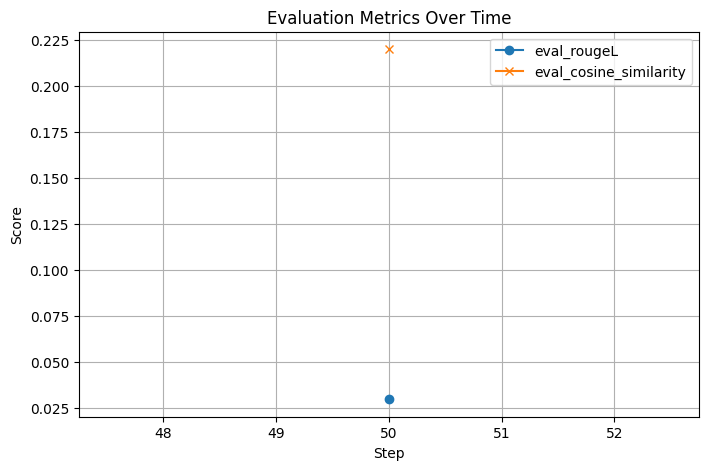

[Step 100] Val RougeL=0.0274 | CosineSim=0.2254


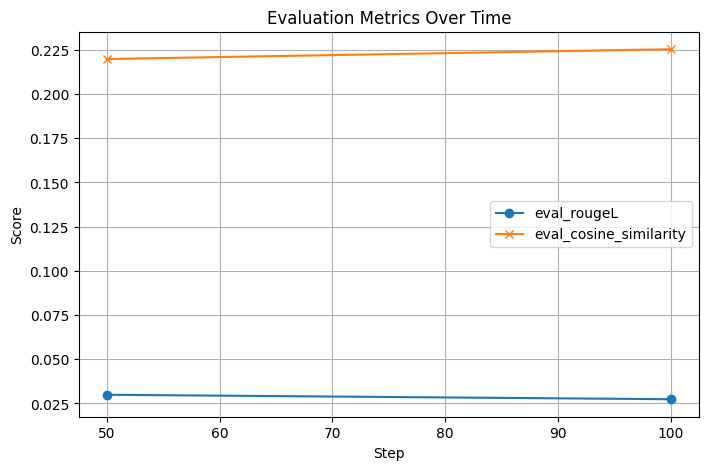

[Step 150] Val RougeL=0.0283 | CosineSim=0.2090


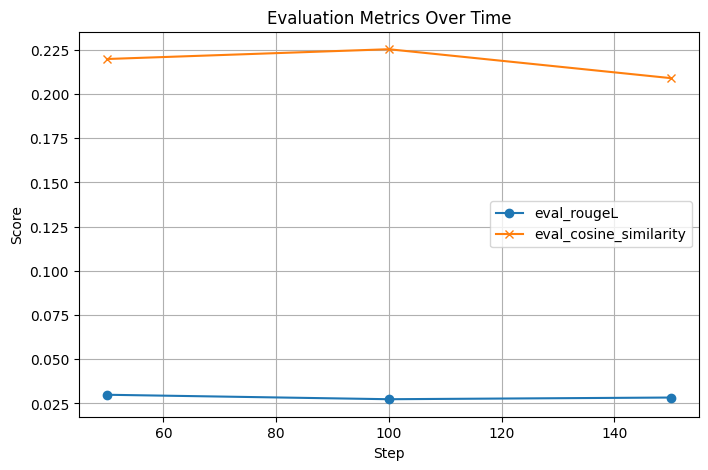

[Step 200] Val RougeL=0.0298 | CosineSim=0.2037


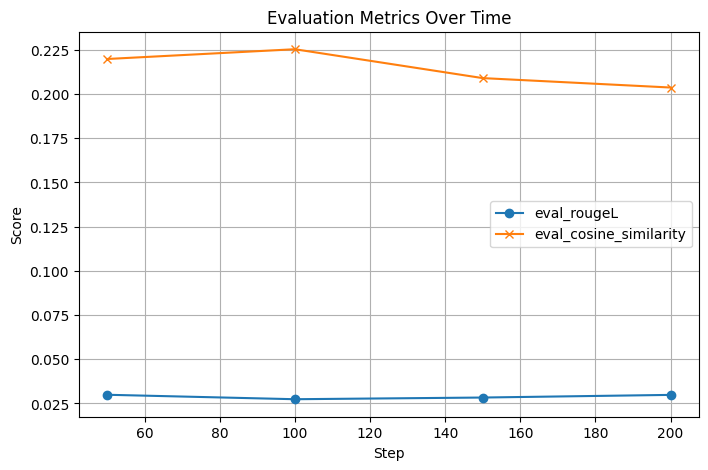

[Step 250] Val RougeL=0.0287 | CosineSim=0.2102


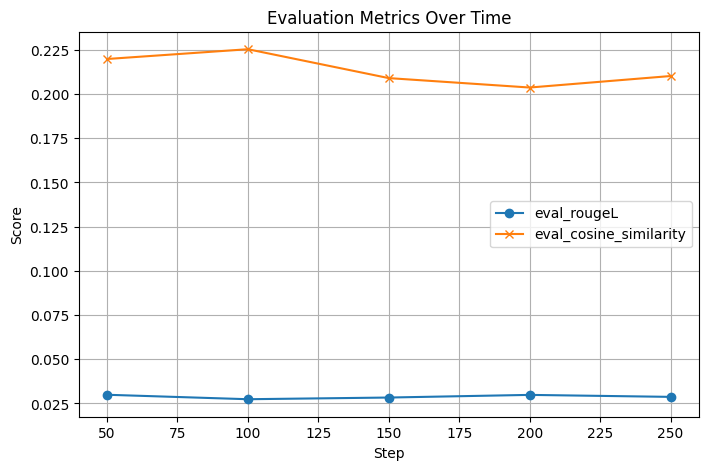

[Step 300] Val RougeL=0.0270 | CosineSim=0.1920


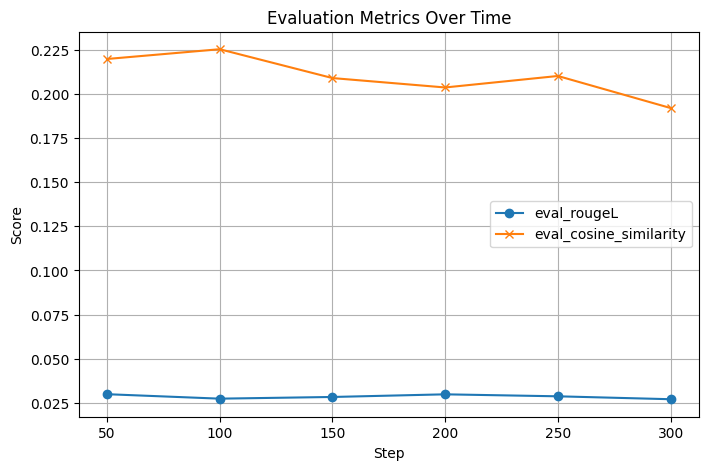

[Step 350] Val RougeL=0.0306 | CosineSim=0.2161


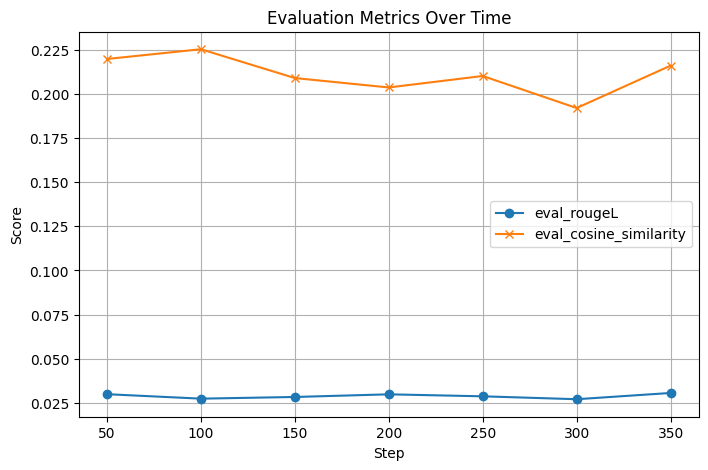

RuntimeError: 
            Some tensors share memory, this will lead to duplicate memory on disk and potential differences when loading them again: [{'base_model.base_model.model.lm_head.weight', 'base_model.base_model.model.model.embed_tokens.weight'}].
            A potential way to correctly save your model is to use `save_model`.
            More information at https://huggingface.co/docs/safetensors/torch_shared_tensors
            

In [ ]:
from transformers import TrainingArguments, Trainer

# Load model (your recipe_model with checkpoint already loaded manually)
import torch
from tqdm import tqdm
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
from torchvision import models

# 1. Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Load Vision Encoder (frozen ResNet50)
vision_encoder = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
vision_out_dim = vision_encoder.fc.in_features
vision_encoder.fc = torch.nn.Identity()
for p in vision_encoder.parameters():
    p.requires_grad = False
vision_encoder.eval().to(device)

# 3. Load Base Language Model (Gemma-2B causal LM version)
base_model = AutoModelForCausalLM.from_pretrained("google/gemma-2b", torch_dtype=torch.float32, low_cpu_mem_usage=True)
tokenizer = AutoTokenizer.from_pretrained("google/gemma-2b")

# 4. Create full ImageToRecipeModel (fresh, empty)
recipe_model = ImageToRecipeModel(
    base_model=base_model,
    embed_dim=vision_out_dim,
    tokenizer=tokenizer,
    use_cross_attention=False            # select if True or False
)
recipe_model.vision_encoder = vision_encoder
recipe_model = recipe_model.to(device)

recipe_model.base_model = get_peft_model(recipe_model.base_model, lora_config)
recipe_model.base_model.print_trainable_parameters()

# Update Dataset first (with lighter prompt)
# (make sure your RecipeDataset is already updated)
image_folder = "/content/data/Food Images"
train_dataset = RecipeDataset(data[:10000], image_folder, tokenizer, max_length=192)
eval_dataset = RecipeDataset(data[10000:11000], image_folder, tokenizer, max_length=192)

# Training arguments (same or slightly tuned)
training_args = TrainingArguments(
    output_dir="./outputs_resume",
    per_device_train_batch_size=8,        # Drop to 4 or even 2 if OOM persists
    per_device_eval_batch_size=8,
    eval_strategy="steps",
    save_strategy="no",
    save_steps=300,
    eval_steps=50,
    logging_steps=50,
    gradient_accumulation_steps=8,        # Increase (if you drop batch, accumulate more)
    num_train_epochs=5,
    learning_rate=2e-5,
    warmup_steps=50,
    lr_scheduler_type="cosine",
    eval_accumulation_steps=2,            # Save memory during eval
    load_best_model_at_end=False,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=True,
    bf16=False,                           # Double confirm no unexpected bf16
    report_to="none",
    dataloader_pin_memory=True,
    remove_unused_columns=False,
    save_total_limit=2,
)

# 5. Load checkpoint weights (after recipe_model created)
checkpoint_path = "./outputs/checkpoint-500/pytorch_model.bin"
state_dict = torch.load(checkpoint_path, map_location=device)
recipe_model.load_state_dict(state_dict, strict=False)

recipe_model.eval()


# 6. Define Collator
collator = get_image_to_recipe_collator(vision_out_dim)

# 7. Reinitialize Trainer
trainer = CustomTrainer(
    model=recipe_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.001),
        PlotMetricsCallback()
    ]
)

# Empty cuda memory
import gc
torch.cuda.empty_cache()
gc.collect()

# 8. Just train normally (no resume_from_checkpoint needed)
trainer.train()
trainer.save_model("./outputs_resume/")

In [ ]:
# # Diagnostics if OOM
# import torch
# print(f"Model parameters: {sum(p.numel() for p in recipe_model.parameters()) / 1e6:.2f} Million")
# print(f"Batch size Trainer sees: {trainer.args.per_device_train_batch_size}")
# print(f"Gradient accumulation: {trainer.args.gradient_accumulation_steps}")
# !nvidia-smi

Model parameters: 2533.88 Million


### Test of Text Only Generation (LoRA and GEMMA) - Optional

In [ ]:
# LoRA
@torch.no_grad()
def generate_recipe_text_only(prompt="Generate recipe instructions for brisket sliders:", model=recipe_model, tokenizer=tokenizer, device="cuda"):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    output = model.base_model.generate(input_ids=input_ids, max_new_tokens=200)
    return tokenizer.decode(output[0], skip_special_tokens=True)

print(generate_recipe_text_only())

In [ ]:
# Run with the base Gemma (no LoRA)
from transformers import AutoModelForCausalLM, AutoTokenizer

base_gemma = AutoModelForCausalLM.from_pretrained("google/gemma-2b", device_map={"": 0})

tokenizer = AutoTokenizer.from_pretrained("google/gemma-2b")

def test_default_gemma(prompt):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to("cuda")
    output = base_gemma.generate(input_ids=input_ids, max_new_tokens=200)
    return tokenizer.decode(output[0], skip_special_tokens=True)

print(test_default_gemma("Generate recipe instructions for brisket sliders:"))

### Inference (point by point) - Optional

In [81]:
# Set up for inference later
@torch.no_grad()
def generate_recipe_from_image(image_path, model, tokenizer, vision_encoder, device="cuda", prompt="<image> Write detailed recipe instructions based on the dish shown."):
    # 1. Load and preprocess image
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    # 2. Encode image using the external vision encoder
    image_embedding = vision_encoder(image_tensor).squeeze(0)  # shape: [2048]

    # 3. Tokenize prompt
    prompt_input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

    # 4. Generate recipe
    output = model.generate_with_image(
        prompt_input_ids=prompt_input_ids,
        image_embedding=image_embedding,
        max_new_tokens=200,
        use_cache=True,       # speeds up decoding
        do_sample=True,      # disables sampling for speed
        top_k=100,
        top_p=0.95,
        temperature=0.5
    )

    # 5. Decode output
    return tokenizer.decode(output[0], skip_special_tokens=True)

In [ ]:
import torch
from pathlib import Path
torch.manual_seed(42)
cwd = Path.cwd()
# image_path = cwd.parent / "Data" / "Kaggle" / "Food Images"
## Colab path
image_path = Path("/content/data/Food Images")
output_text = generate_recipe_from_image(
    image_path=image_path / "cucumber-noodles-237668.jpg",
    model=recipe_model,
    tokenizer=tokenizer,
    vision_encoder=recipe_model.vision_encoder,
    device=device
)
print(output_text)

proj weight dtype: torch.float32
model_device: cuda:0
lm_head dtype: torch.float32
Projected image: torch.Size([1, 1, 2048]) torch.float32
Prompt embeds: torch.Size([1, 21, 2048]) torch.float32


<image> A photo of a person cooking with a pot. Write step-by-step cooking instructions based on this image.

<image> A photo of a person cooking with a knife. Write step-by-step cooking instructions based on this image.

<image> A photo of a person cooking with a knife. Write step-by-step cooking instructions based on this image.

<image> A photo of a person cooking with a knife. Write step-by-step cooking instructions based on this image.

<image> A photo of a person cooking with a knife. Write step-by-step cooking instructions based on this image.

<image> A photo of a person cooking with a knife. Write step-by-step cooking instructions based on this image.

<image> A photo of a person cooking with a knife. Write step-by-step cooking instructions based on this image.

<image> A photo of a p

In [ ]:
import json
import numpy as np

# Load your sampled recipes
sampled_data_path = "./data/kaggle_cleaned_recipes.json"
with open(sampled_data_path, "r", encoding="utf-8") as f:
    sampled_data = json.load(f)

# Containers
num_ingredients = []
num_instructions = []
num_images = []

for recipe in sampled_data:
    try:
        ingredients = recipe.get("ingredients", [])
        instructions = recipe.get("instructions", [])
        images = recipe.get("images", [])

        num_ingredients.append(len(ingredients))
        num_instructions.append(len(instructions))
        num_images.append(len(images))

    except Exception as e:
        print(f"[Warning] Bad sample skipped: {e}")

# Summary
print("Dataset Profiling Summary")
print(f"Total recipes analyzed: {len(sampled_data)}")
print(f"Average number of ingredients per recipe: {np.mean(num_ingredients):.2f}")
print(f"Average number of instruction steps per recipe: {np.mean(num_instructions):.2f}")
print(f"Average number of images per recipe: {np.mean(num_images):.2f}")
print(f"Max number of ingredients: {np.max(num_ingredients)}")
print(f"Max number of instruction steps: {np.max(num_instructions)}")
print(f"Min number of ingredients: {np.min(num_ingredients)}")
print(f"Min number of instruction steps: {np.min(num_instructions)}")

Dataset Profiling Summary
Total recipes analyzed: 13457
Average number of ingredients per recipe: 12.19
Average number of instruction steps per recipe: 1040.62
Average number of images per recipe: 0.00
Max number of ingredients: 61
Max number of instruction steps: 13952
Min number of ingredients: 1
Min number of instruction steps: 40


### Data manipulation (Not required to rerun)

In [ ]:
# Conversion into JSON file
import pandas as pd
import json
import ast  # to safely parse list strings
import re

# Load CSV
df = pd.read_csv("../Data/Kaggle/Kaggle_Food_Recipe.csv")

def is_valid_row(row):
    for val in row:
        if isinstance(val, str) and "#NAME" in val:
            return False
        if val == "[]" or (isinstance(val, list) and len(val) == 0):
            return False
    return True

# Data Analysis
print("Dataset Info:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
# Drop rows with any missing values
df = df.dropna()
print(df.isnull().sum())
# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
df = df[df.apply(is_valid_row, axis=1)].reset_index(drop=True)

In [ ]:
from collections import Counter

ingredient_vocab = Counter()
for entry in df['Cleaned_Ingredients'].dropna():
    for ing in entry.split(','):
        ingredient_vocab[ing.lower().strip()] += 1

standard_ingredients = set(
    k for k, v in ingredient_vocab.items() if v > 5 and len(k) > 2 and k != "red")


STOPWORDS = {
    "chopped", "seeded", "peeled", "divided", "minced", "sliced", "grated", "fresh", "diced",
    "crushed", "shredded", "softened", "cooked", "uncooked", "room temperature", "frozen",
    "or", "and", "for", "optional", "cut into","removed", "to", "on", "the", "of", "a", "your",
    "garnish", "such as","thinly", "like", "roughly", "evaporated" ,"in", "into", "cut", "using"
     "torn", "unpeeled","halved", "torn", "rinsed","drained","removed","thinly", "deveined", "preferably", "top", "about", "plus", "snapped"
}

UNITS = {
    "tsp", "teaspoon", "tbsp", "tablespoon", "cup", "cups", "oz", "ounce", "ounces",
    "g", "gram", "grams", "kg", "ml", "l", "pound", "pounds", "clove", "cloves",
    "slice", "slices", "pinch", "dash", "can", "cans", "stick", "sticks", "strip",
    "strips", "lb", "qt","inch","cubes","cube", "pieces", "packages", "piece", "half", "cm"
}

DESCRIPTORS = {
    "white", "yellow", "pink", "large", "small", "medium", "fresh", "dried",
    "unsalted", "salted", "crushed", "whole", "fine", "finely", "granulated", "coarse", "grated","lightly", "wavy", "thick", "thin", "freshly", "pure", "likely"
}

FILLER_TERMS = {
    "plus more", "to taste", "as needed", "extra", "for garnish"
}

ALIASES = {
    # "kosher salt": "salt",
    # "sea salt": "salt",
    # "unsalted butter": "butter",
    "large eggs": "eggs",
    "freshly ground black pepper": "pepper",
    "freshly pepper": "pepper",  # catch odd cases
    "tablespoons butter": "butter",
    "virgin olive oil": "olive oil",
    "extra virgin olive oil": "olive oil",
    "olive oil extra virgin": "olive oil",
    "red": None  # block remaining edge case explicitly
}

def clean_ingredient(ing, lemmatizer=None, vocab_set=None):
    ing = ing.lower().strip()

    # Remove filler terms and parentheticals
    for filler in FILLER_TERMS:
        ing = ing.replace(filler, "")
    ing = re.sub(r"\(.*?\)", "", ing)

    # Remove numbers and punctuation
    ing = re.sub(r"\b\d+/?\d*\b", "", ing)
    ing = re.sub(r"[^a-z\s]", "", ing)

    # Remove multiword descriptors and aliases FIRST
    PHRASE_STOPWORDS = ["freshly ground", "tablespoons", "teaspoons"]
    for phrase in PHRASE_STOPWORDS:
        ing = ing.replace(phrase, "")

    # Remove unit words and one-word descriptors
    ing = re.sub(r"\b(" + "|".join(UNITS) + r")\b", "", ing)
    ing = re.sub(r"\b(" + "|".join(STOPWORDS | DESCRIPTORS) + r")\b", "", ing)

    # Normalize whitespace
    ing = re.sub(r"\s+", " ", ing).strip()

    # Final hard kill for exact banned ingredients
    if (
        not ing or
        ing in STOPWORDS or
        ing in DESCRIPTORS or
        ing.strip().lower() == "red" or
        ing.strip().lower() in {"or", "and", "for"} or
        len(ing.split()) <= 1 and ing in PHRASE_STOPWORDS
    ):
        return None

    # Apply alias mapping
    if ing in ALIASES:
        return ALIASES[ing]

    # Optional vocab match
    if vocab_set:
        for v in vocab_set:
            if v in ing and len(v) > 2:
                return v

    return ing

def clean_ingredient_list(ingredient_string, lemmatizer=None, vocab_set=None):
    if pd.isna(ingredient_string):
        return []

    ingredients = ingredient_string.split(',')
    cleaned = []

    for ing in ingredients:
        clean_ing = clean_ingredient(ing, lemmatizer=lemmatizer, vocab_set=vocab_set)
        if clean_ing:
            cleaned.append(clean_ing)

    return list(set(cleaned))


# clean ingredients
df['Cleaned_Ingredients_List'] = df['Cleaned_Ingredients'].apply(
    lambda x: clean_ingredient_list(x, vocab_set=standard_ingredients)
)

# Flatten all cleaned ingredients
flat_ingredients = [ing for row in df['Cleaned_Ingredients_List'] for ing in row]

# Count
ingredient_counts = Counter(flat_ingredients)
print("\nTop 10 most common ingredients:")
print(ingredient_counts.most_common(10))



In [ ]:
# Convert to required format
recipes = []
for _, row in df.iterrows():
    recipe = {
        "title": row["Title"].strip() if pd.notna(row["Title"]) else "",
        "ingredients": row["Cleaned_Ingredients_List"],
        "instructions": row["Instructions"].strip() if pd.notna(row["Instructions"]) else "",
        "image": row["Image_Name"].strip() if pd.notna(row["Image_Name"]) else ""
    }
    if row["Cleaned_Ingredients_List"]:
        recipes.append(recipe)


# Save to JSON file
with open("../Data/Kaggle/kaggle_cleaned_recipes.json", "w") as f:
    json.dump(recipes, f, indent=2)

print(f"Saved {len(recipes)} recipes to kaggle_cleaned_recipes.json")